In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import ipywidgets as widgets
from ipywidgets import VBox, HBox, Layout
from IPython.display import display, clear_output
from scipy.spatial.distance import pdist
import random

## Objective Function

In [1]:
# To be adjusted
def calculate_suitability(row, w0=0.8, w1=0.3, w2=-0.2, w3=-0.2):
    return w0 * row['ALLSKY_SFC_SW_DWN'] + w1 * row['ALLSKY_KT'] + w2 * row['CLOUD_AMT'] + w3 * row['PRECTOTCORR']


## Genetic Algo

In [60]:
def genetic_algorithm(df, population_size, generations, mutation_rate, num_points=20, verbose=False):
    df = df.copy()

    def fitness_function(point_indices):
        points = df.loc[point_indices]
        suitability_score = points['avg_score'].sum()

        # --- Grid proximity penalty ---
        penalty = 0
        lat_array = points['lat'].values
        lon_array = points['lon'].values

        for i in range(len(points)):
            for j in range(i + 1, len(points)):
                lat_diff_km = abs(lat_array[i] - lat_array[j]) * 111
                lon_diff_km = abs(lon_array[i] - lon_array[j]) * 86.25
                distance_km = np.sqrt(lat_diff_km**2 + lon_diff_km**2)

                if distance_km < 100:
                    penalty += 1 / (distance_km + 1e-6)

        lambda_penalty = 10
        return suitability_score - lambda_penalty * penalty

    def create_initial_population():
        return [np.random.choice(df.index, num_points, replace=False) for _ in range(population_size)]

    def selection(population, fitnesses):
        indices = np.argsort(fitnesses)
        return [population[i] for i in indices[-(population_size // 2):]]

    def crossover(parent1, parent2):
        point = random.randint(1, len(parent1) - 1)
        child1 = np.concatenate((parent1[:point], parent2[point:]))
        child2 = np.concatenate((parent2[:point], parent1[point:]))
        return child1, child2

    def mutate(individual, mutation_rate):
        if random.random() < mutation_rate:
            idx = random.randint(0, len(individual) - 1)
            new_point = random.choice([i for i in df.index if i not in individual])
            individual[idx] = new_point

    fitness_scores = []
    population = create_initial_population()
    best_individual = None
    best_fitness = -float('inf')

    for generation in range(generations):
        fitnesses = [fitness_function(ind) for ind in population]

        if max(fitnesses) > best_fitness:
            best_fitness = max(fitnesses)
            best_individual = population[np.argmax(fitnesses)]

        selected = selection(population, fitnesses)
        next_generation = []

        while len(next_generation) < population_size:
            parents = random.sample(selected, 2)
            offspring1, offspring2 = crossover(parents[0], parents[1])
            mutate(offspring1, mutation_rate)
            mutate(offspring2, mutation_rate)
            next_generation.extend([offspring1, offspring2])

        population = next_generation[:population_size]

        if verbose and generation % 10 == 0:
            print(f"Generation {generation + 1}, Best Fitness: {best_fitness:.4f}")

        fitness_scores.append(best_fitness)

    best_points = df.loc[best_individual]
    best_points.to_csv('best_20_points_ga_penalty.csv', index=False)
    print("Best 20 points saved to 'best_20_points_ga_penalty.csv'")

    return best_individual, best_fitness, fitness_scores


# Run the algorithm with fixed parameters
if __name__ == "__main__":
    file_path = r"lat_lon_avg_score.csv"
    df_input = pd.read_csv(file_path)

    
    best_assignment, best_fitness, fitness_scores = genetic_algorithm(
        df=df_input,
        population_size=50,
        generations=300,
        mutation_rate=0.2,
        num_points=20,
        verbose=True
    )


Generation 1, Best Fitness: 10.4342
Generation 11, Best Fitness: 12.3300
Generation 21, Best Fitness: 13.1391
Generation 31, Best Fitness: 13.4542
Generation 41, Best Fitness: 13.5719
Generation 51, Best Fitness: 13.6444
Generation 61, Best Fitness: 13.7752
Generation 71, Best Fitness: 13.7752
Generation 81, Best Fitness: 13.8393
Generation 91, Best Fitness: 13.9689
Generation 101, Best Fitness: 14.0407
Generation 111, Best Fitness: 14.0407
Generation 121, Best Fitness: 14.0789
Generation 131, Best Fitness: 14.0943
Generation 141, Best Fitness: 14.1421
Generation 151, Best Fitness: 14.1807
Generation 161, Best Fitness: 14.2416
Generation 171, Best Fitness: 14.2416
Generation 181, Best Fitness: 14.2652
Generation 191, Best Fitness: 14.2652
Generation 201, Best Fitness: 14.2652
Generation 211, Best Fitness: 14.2652
Generation 221, Best Fitness: 14.2652
Generation 231, Best Fitness: 14.2842
Generation 241, Best Fitness: 14.2989
Generation 251, Best Fitness: 14.2989
Generation 261, Best Fi

## Genetic Algorithm vs Highest suitability scores strategy


In [30]:
# Load the dataset with lat, lon, and avg_score
df = pd.read_csv("lat_lon_avg_score.csv")

# Select the top 20 points with the highest avg_score
top_20_points = df.nlargest(20, 'avg_score')

# Save to CSV
output_path_top20 = "top_20_points_direct.csv"
top_20_points.to_csv(output_path_top20, index=False)

output_path_top20


'top_20_points_direct.csv'

In [ ]:
# Load both sets
ga_points = pd.read_csv("best_20_points_ga_penalty.csv")
direct_top20 = pd.read_csv("top_20_points_direct.csv")

def evaluate_point_set(df):
    coords = df[['lat', 'lon']].values
    distances = pdist(coords)  # pairwise haversine distance would be better, but Euclidean is okay for relative comparison
    mean_distance = np.mean(distances)
    mean_score = df['avg_score'].mean()
    return mean_distance, mean_score

ga_mean_distance, ga_mean_score = evaluate_point_set(ga_points)
direct_mean_distance, direct_mean_score = evaluate_point_set(direct_top20)

# Bundle results into a comparison DataFrame
comparison_df = pd.DataFrame({
    'Method': ['Genetic Algorithm', 'Top-20 Direct'],
    'Mean Distance Between Points': [ga_mean_distance, direct_mean_distance],
    'Mean Suitability Score': [ga_mean_score, direct_mean_score]
})

comparison_df


,Method,Mean Distance Between Points,Mean Suitability Score
0,Genetic Algorithm,5.855133,0.699043
1,Top-20 Direct,4.308333,0.785067


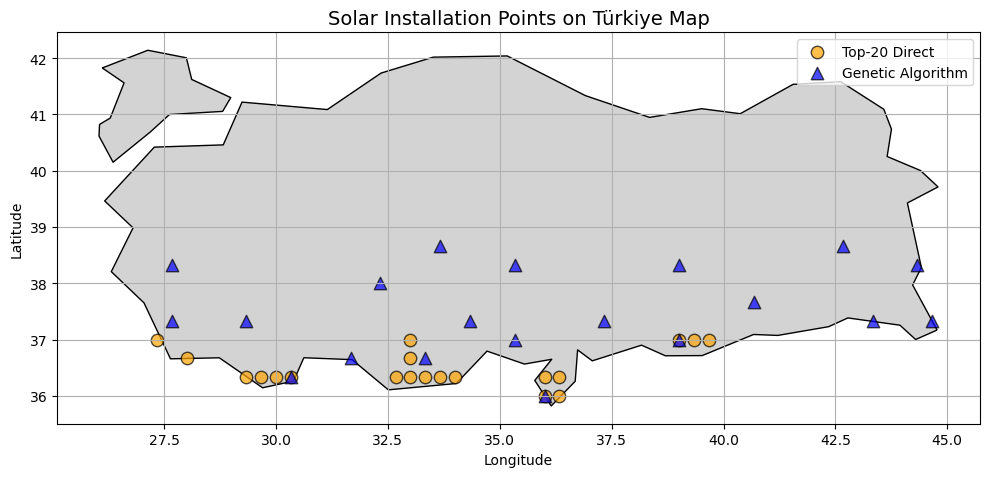

In [ ]:
# Load countries shapefile manually
world = gpd.read_file("ne_110m_admin_0_countries.shp")

# Filter just Turkey
turkey = world[world["ADMIN"] == "Turkey"]


# Load both datasets
ga_points = pd.read_csv('best_20_points_ga_penalty.csv')
direct_points = pd.read_csv('top_20_points_direct.csv')

# Convert to GeoDataFrames
gdf_ga = gpd.GeoDataFrame(
    ga_points,
    geometry=gpd.points_from_xy(ga_points.lon, ga_points.lat),
    crs="EPSG:4326"
)

gdf_direct = gpd.GeoDataFrame(
    direct_points,
    geometry=gpd.points_from_xy(direct_points.lon, direct_points.lat),
    crs="EPSG:4326"
)

# Plot
fig, ax = plt.subplots(figsize=(10, 12))
turkey.plot(ax=ax, color='lightgray', edgecolor='black')

# Plot both sets with transparency and borders
gdf_direct.plot(ax=ax, color='orange', marker='o', markersize=80, label='Top-20 Direct', edgecolor='black', alpha=0.7)
gdf_ga.plot(ax=ax, color='blue', marker='^', markersize=80, label='Genetic Algorithm', edgecolor='black', alpha=0.7)

# Aesthetics
plt.title("Solar Installation Points on Türkiye Map", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Experiments with GA


In [ ]:
# initializing the experiment variables
pop_size = [25,50,75,100]
mut_rate = [0.05,0.1,0.2,0.3]
gens = [100,500,1000,2000]

In [13]:
pop_results = []

for pop in pop_size:
    best_assignment, best_fitness, fitness_scores = genetic_algorithm(
        df=df_input.copy(),       # ensure original data is preserved
        population_size=pop,
        generations=100,
        mutation_rate=0.2,
        num_points=20,
        verbose=True
    )
    print(f"Population Size: {pop}, Best Fitness: {best_fitness}")
    pop_results.append([best_assignment, best_fitness, fitness_scores])


Generation 1, Best Fitness: 9.8638
Generation 11, Best Fitness: 11.5601
Generation 21, Best Fitness: 12.6085
Generation 31, Best Fitness: 12.8142
Generation 41, Best Fitness: 12.9080
Generation 51, Best Fitness: 13.1650
Generation 61, Best Fitness: 13.4995
Generation 71, Best Fitness: 13.5366
Generation 81, Best Fitness: 13.5435
Generation 91, Best Fitness: 13.6814
Best 20 points saved to 'best_20_points_ga_penalty.csv'
Population Size: 25, Best Fitness: 13.709547972358745
Generation 1, Best Fitness: 10.1129
Generation 11, Best Fitness: 12.1980
Generation 21, Best Fitness: 13.0556
Generation 31, Best Fitness: 13.5770
Generation 41, Best Fitness: 13.6741
Generation 51, Best Fitness: 13.8908
Generation 61, Best Fitness: 13.8908
Generation 71, Best Fitness: 13.9246
Generation 81, Best Fitness: 13.9508
Generation 91, Best Fitness: 13.9902
Best 20 points saved to 'best_20_points_ga_penalty.csv'
Population Size: 50, Best Fitness: 14.080632856875269
Generation 1, Best Fitness: 10.3395
Generat

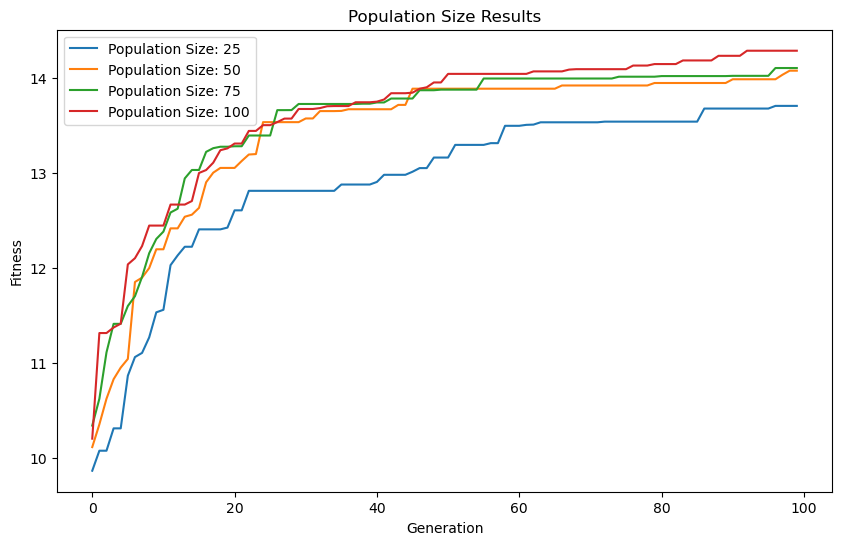

In [ ]:
plt.figure(figsize=(10, 6))
for i, result in enumerate(pop_results):
    plt.plot(result[2], label=f"Population Size: {pop_size[i]}")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()
plt.title("Population Size Results")
plt.show()

In [15]:
mut_results = []
for mut in mut_rate:
    best_assignment, best_fitness, fitness_scores = best_assignment, best_fitness, fitness_scores = genetic_algorithm(
        df=df_input.copy(),       # ensure original data is preserved
        population_size=50,
        generations=100,
        mutation_rate=mut,
        num_points=20,
        verbose=True
    )
    print(f"Mutation Rate: {mut}, Best Fitness: {best_fitness}")
    mut_results.append([best_assignment, best_fitness, fitness_scores])

Generation 1, Best Fitness: 10.5233
Generation 11, Best Fitness: 12.5026
Generation 21, Best Fitness: 13.0934
Generation 31, Best Fitness: 13.1049
Generation 41, Best Fitness: 13.3266
Generation 51, Best Fitness: 13.6726
Generation 61, Best Fitness: 13.6726
Generation 71, Best Fitness: 13.8622
Generation 81, Best Fitness: 13.8898
Generation 91, Best Fitness: 13.8898
Best 20 points saved to 'best_20_points_ga_penalty.csv'
Mutation Rate: 0.05, Best Fitness: 13.93621
Generation 1, Best Fitness: 10.4055
Generation 11, Best Fitness: 12.7592
Generation 21, Best Fitness: 13.8362
Generation 31, Best Fitness: 13.8368
Generation 41, Best Fitness: 13.9321
Generation 51, Best Fitness: 13.9329
Generation 61, Best Fitness: 13.9479
Generation 71, Best Fitness: 13.9479
Generation 81, Best Fitness: 13.9479
Generation 91, Best Fitness: 13.9845
Best 20 points saved to 'best_20_points_ga_penalty.csv'
Mutation Rate: 0.1, Best Fitness: 13.984484683711962
Generation 1, Best Fitness: 10.6846
Generation 11, Be

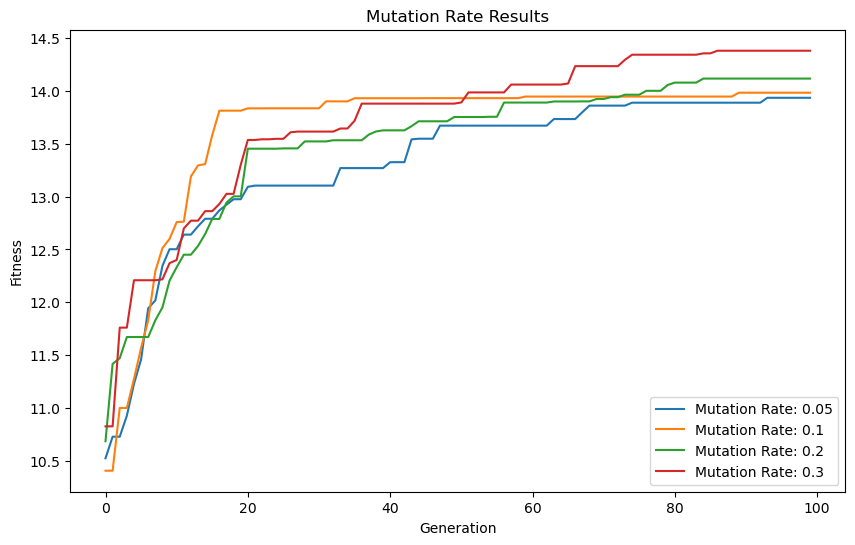

In [ ]:
plt.figure(figsize=(10, 6))
for mut, result in zip(mut_rate, mut_results):
    plt.plot(result[2], label=f"Mutation Rate: {mut}")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("Mutation Rate Results")
plt.legend()
plt.show()

In [ ]:
# Load your dataset
file_path = r"lat_lon_avg_score.csv"
df_input = pd.read_csv(file_path)

# Run the genetic algorithm
best_assignment, best_fitness, fitness_scores = genetic_algorithm(
    df=df_input.copy(),
    population_size=50,
    generations=2000,
    mutation_rate=0.2,
    num_points=20,
    verbose=True
)

Generation 1, Best Fitness: 10.5700
Generation 11, Best Fitness: 12.1596
Generation 21, Best Fitness: 12.8242
Generation 31, Best Fitness: 13.1845
Generation 41, Best Fitness: 13.6421
Generation 51, Best Fitness: 13.8020
Generation 61, Best Fitness: 13.8606
Generation 71, Best Fitness: 14.0580
Generation 81, Best Fitness: 14.0580
Generation 91, Best Fitness: 14.0580
Generation 101, Best Fitness: 14.0580
Generation 111, Best Fitness: 14.0580
Generation 121, Best Fitness: 14.0729
Generation 131, Best Fitness: 14.0729
Generation 141, Best Fitness: 14.0729
Generation 151, Best Fitness: 14.0729
Generation 161, Best Fitness: 14.0732
Generation 171, Best Fitness: 14.1191
Generation 181, Best Fitness: 14.1722
Generation 191, Best Fitness: 14.1956
Generation 201, Best Fitness: 14.2739
Generation 211, Best Fitness: 14.2739
Generation 221, Best Fitness: 14.3397
Generation 231, Best Fitness: 14.3397
Generation 241, Best Fitness: 14.3397
Generation 251, Best Fitness: 14.3578
Generation 261, Best Fi

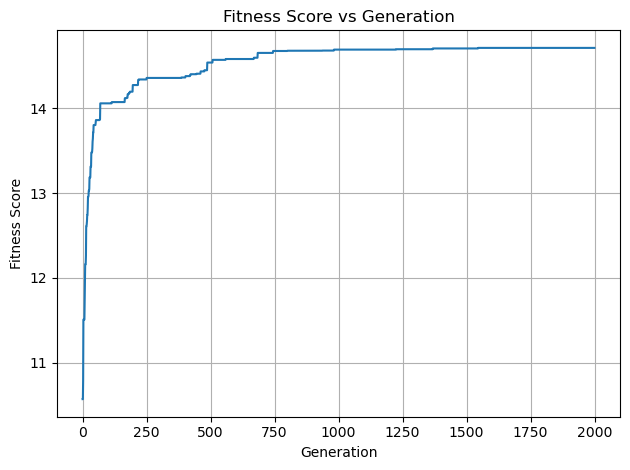

In [18]:
# Plot the fitness scores
plt.plot(fitness_scores)
plt.xlabel("Generation")
plt.ylabel("Fitness Score")
plt.title("Fitness Score vs Generation")
plt.grid(True)
plt.tight_layout()
plt.show()

## Interactive GA

In [6]:
# --- Load your data ---
df_input = pd.read_csv("lat_lon_avg_score.csv")

# --- Genetic Algorithm definition (from your notebook) ---
import random

def genetic_algorithm(df, population_size, generations, mutation_rate, num_points=20, verbose=False):
    df = df.copy()

    def fitness_function(point_indices):
        points = df.loc[point_indices]
        suitability_score = points['avg_score'].sum()
        penalty = 0
        lat_array = points['lat'].values
        lon_array = points['lon'].values
        for i in range(len(points)):
            for j in range(i + 1, len(points)):
                lat_diff_km = abs(lat_array[i] - lat_array[j]) * 111
                lon_diff_km = abs(lon_array[i] - lon_array[j]) * 86.25
                distance_km = np.sqrt(lat_diff_km**2 + lon_diff_km**2)
                if distance_km < 100:
                    penalty += 1 / (distance_km + 1e-6)
        lambda_penalty = 10
        return suitability_score - lambda_penalty * penalty

    def create_initial_population():
        return [np.random.choice(df.index, num_points, replace=False) for _ in range(population_size)]

    def selection(population, fitnesses):
        indices = np.argsort(fitnesses)
        return [population[i] for i in indices[-(population_size // 2):]]

    def crossover(parent1, parent2):
        point = random.randint(1, len(parent1) - 1)
        child1 = np.concatenate((parent1[:point], parent2[point:]))
        child2 = np.concatenate((parent2[:point], parent1[point:]))
        return child1, child2

    def mutate(individual, mutation_rate):
        if random.random() < mutation_rate:
            idx = random.randint(0, len(individual) - 1)
            new_point = random.choice([i for i in df.index if i not in individual])
            individual[idx] = new_point

    fitness_scores = []
    population = create_initial_population()
    best_individual = None
    best_fitness = -float('inf')

    for generation in range(generations):
        fitnesses = [fitness_function(ind) for ind in population]
        if max(fitnesses) > best_fitness:
            best_fitness = max(fitnesses)
            best_individual = population[np.argmax(fitnesses)]
        selected = selection(population, fitnesses)
        next_generation = []
        while len(next_generation) < population_size:
            parents = random.sample(selected, 2)
            offspring1, offspring2 = crossover(parents[0], parents[1])
            mutate(offspring1, mutation_rate)
            mutate(offspring2, mutation_rate)
            next_generation.extend([offspring1, offspring2])
        population = next_generation[:population_size]
        if verbose and generation % 10 == 0:
            print(f"Generation {generation + 1}, Best Fitness: {best_fitness:.4f}")
        fitness_scores.append(best_fitness)
    best_points = df.loc[best_individual]
    best_points.to_csv('best_20_points_ga_penalty.csv', index=False)
    print("Best 20 points saved to 'best_20_points_ga_penalty.csv'")
    return best_individual, best_fitness, fitness_scores

# --- Layouts ---
slider_layout = Layout(width='600px', height='50px')
button_layout = Layout(width='300px', height='50px')

# --- Sliders ---
population_slider = widgets.IntSlider(
    value=50, min=25, max=100, step=10,
    description='👥 Population:', style={'description_width': '150px'},
    layout=slider_layout
)
mutation_slider = widgets.FloatSlider(
    value=0.2, min=0.01, max=1, step=0.01,
    description='🧬 Mutation Rate:', style={'description_width': '150px'},
    layout=slider_layout
)
generation_slider = widgets.IntSlider(
    value=300, min=50, max=2000, step=50,
    description='🔁 Generations:', style={'description_width': '150px'},
    layout=slider_layout
)

# --- Buttons ---
run_button = widgets.Button(
    description="🚀 Run Optimization",
    button_style='success',
    layout=button_layout
)
reset_button = widgets.Button(
    description="🔄 Reset",
    button_style='warning',
    layout=button_layout
)

# --- Output box ---
output = widgets.Output()

# --- Run callback ---
def on_button_click(b):
    with output:
        clear_output(wait=True)
        best_assignment, best_fitness, fitness_scores = genetic_algorithm(
            df=df_input.copy(),
            population_size=population_slider.value,
            generations=generation_slider.value,
            mutation_rate=mutation_slider.value,
            num_points=20,
            verbose=True
        )
        # Fitness Plot
        fig1, ax1 = plt.subplots(figsize=(8, 4), constrained_layout=True)
        ax1.plot(fitness_scores, marker='o', color='mediumseagreen')
        ax1.set_title("📈 Fitness Score per Generation")
        ax1.set_xlabel("Generation")
        ax1.set_ylabel("Best Fitness")
        ax1.grid(True)
        plt.show()
        # Map Plot
        world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
        turkey = world[world.name == "Turkey"]
        selected_points = pd.read_csv('best_20_points_ga_penalty.csv')
        gdf_points = gpd.GeoDataFrame(
            selected_points,
            geometry=gpd.points_from_xy(selected_points.lon, selected_points.lat),
            crs="EPSG:4326"
        )
        fig2, ax2 = plt.subplots(figsize=(8, 10), constrained_layout=True)
        turkey.plot(ax=ax2, color='whitesmoke', edgecolor='black')
        gdf_points.plot(ax=ax2, color='crimson', markersize=50, edgecolor='white')
        ax2.set_title("📍 Selected Solar Installation Points on Türkiye Map", fontsize=14)
        ax2.set_xlabel("Longitude")
        ax2.set_ylabel("Latitude")
        ax2.grid(True)
        plt.show()

# --- Reset callback ---
def on_reset_click(b):
    population_slider.value = 50
    mutation_slider.value = 0.2
    generation_slider.value = 300
    output.clear_output()

# --- Remove duplicate bindings and bind cleanly ---
def clear_and_bind(widget, callback):
    try:
        widget._click_handlers.callbacks.clear()
    except Exception:
        pass
    widget.on_click(callback)

clear_and_bind(run_button, on_button_click)
clear_and_bind(reset_button, on_reset_click)


# --- Layout container ---
button_row = HBox([run_button, reset_button], layout=Layout(justify_content='center', gap='20px'))
control_box = VBox(
    [population_slider, mutation_slider, generation_slider, button_row],
    layout=Layout(
        border='2px solid lightgray',
        border_radius='10px',
        box_shadow='2px 2px 5px rgba(0,0,0,0.1)',
        padding='20px',
        width='700px',
        align_items='center',
        background_color='white'
    )
)

# --- Output box with wider layout ---
output.layout = Layout(width='900px', align_items='center')

if not hasattr(run_button, "_already_displayed"):
    display(VBox([control_box, widgets.HBox([output], layout=Layout(justify_content='center', width='100%'))], 
                 layout=Layout(align_items='center', width='100%')))
    run_button._already_displayed = True

## Particle Swarm

In [31]:
class Particle:
    def __init__(self, df, num_points):
        self.df = df
        self.num_points = num_points
        
        # Initialize particle with random selection of points
        self.position = np.random.choice(df.index, num_points, replace=False)
        self.velocity = []  # Not used in this discrete version
        self.best_position = self.position.copy()
        self.best_score = self.fitness(self.position)

    def fitness(self, indices):
        points = self.df.loc[indices]
        suitability_score = points['avg_score'].sum()

        # Apply penalty for points that are too close to each other
        penalty = 0
        lat_array = points['lat'].values
        lon_array = points['lon'].values

        for i in range(len(points)):
            for j in range(i + 1, len(points)):
                lat_diff_km = abs(lat_array[i] - lat_array[j]) * 111  # approx. km/degree
                lon_diff_km = abs(lon_array[i] - lon_array[j]) * 86.25
                distance_km = np.sqrt(lat_diff_km**2 + lon_diff_km**2)

                if distance_km < 100:
                    penalty += 1 / (distance_km + 1e-6)  # Avoid division by zero

        lambda_penalty = 10
        return suitability_score - lambda_penalty * penalty

    def update(self, global_best):
        new_position = self.position.copy()

        # Replace points based on personal and global bests
        for i in range(len(self.position)):
            if random.random() < 0.5:
                new_position[i] = global_best[i]
            elif random.random() < 0.5:
                new_position[i] = self.best_position[i]

        # Ensure all selected indices are unique
        self.position = np.unique(new_position)
        while len(self.position) < self.num_points:
            candidate = random.choice(self.df.index)
            if candidate not in self.position:
                self.position = np.append(self.position, candidate)

        # Update personal best
        current_score = self.fitness(self.position)
        if current_score > self.best_score:
            self.best_position = self.position.copy()
            self.best_score = current_score


In [32]:
def particle_swarm_optimization(df, num_particles=30, iterations=35, num_points=20, verbose=True):
    df = df.copy()
    swarm = [Particle(df, num_points) for _ in range(num_particles)]

    # Initialize global best
    global_best_position = swarm[0].position.copy()
    global_best_score = swarm[0].fitness(global_best_position)

    best_scores = []

    for iteration in range(iterations):
        # Linear inertia decay from 0.9 to 0.3
        inertia = 0.9 - iteration * ((0.9 - 0.3) / iterations)

        for particle in swarm:
            particle.update(global_best_position)

            if particle.best_score > global_best_score:
                global_best_position = particle.best_position.copy()
                global_best_score = particle.best_score

        best_scores.append(global_best_score)

        if verbose and iteration % 5 == 0:
            print(f"Iteration {iteration + 1}, Inertia: {inertia:.3f}, Best Fitness: {global_best_score:.4f}")

    # Save results
    best_points_df = df.loc[global_best_position]
    best_points_df.to_csv('best_20_points_pso.csv', index=False)
    print("Best 20 points saved to 'best_20_points_pso.csv'")

    return global_best_position, global_best_score, best_scores


In [33]:
best_assignment, best_fitness, fitness_scores = particle_swarm_optimization(
    df=df,
    num_particles=50,
    iterations=100,
    num_points=20,
    verbose=True
)


Iteration 1, Inertia: 0.900, Best Fitness: 10.9300
Iteration 6, Inertia: 0.870, Best Fitness: 12.2498
Iteration 11, Inertia: 0.840, Best Fitness: 13.0372
Iteration 16, Inertia: 0.810, Best Fitness: 13.1744
Iteration 21, Inertia: 0.780, Best Fitness: 13.5437
Iteration 26, Inertia: 0.750, Best Fitness: 13.6246
Iteration 31, Inertia: 0.720, Best Fitness: 13.6246
Iteration 36, Inertia: 0.690, Best Fitness: 13.6641
Iteration 41, Inertia: 0.660, Best Fitness: 13.6641
Iteration 46, Inertia: 0.630, Best Fitness: 13.6641
Iteration 51, Inertia: 0.600, Best Fitness: 13.7071
Iteration 56, Inertia: 0.570, Best Fitness: 13.8404
Iteration 61, Inertia: 0.540, Best Fitness: 13.8404
Iteration 66, Inertia: 0.510, Best Fitness: 13.8707
Iteration 71, Inertia: 0.480, Best Fitness: 13.9073
Iteration 76, Inertia: 0.450, Best Fitness: 13.9073
Iteration 81, Inertia: 0.420, Best Fitness: 13.9073
Iteration 86, Inertia: 0.390, Best Fitness: 13.9073
Iteration 91, Inertia: 0.360, Best Fitness: 13.9073
Iteration 96, 

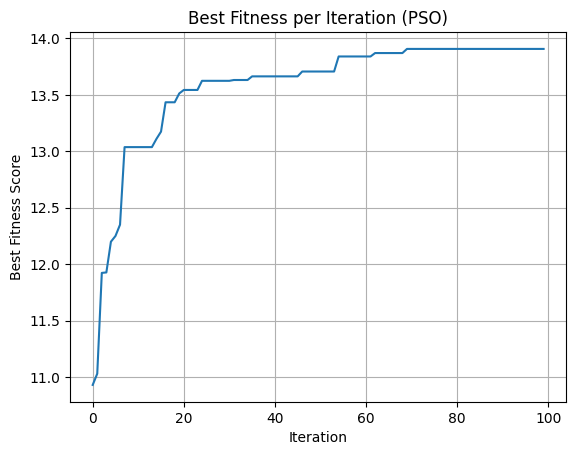

In [34]:
plt.plot(fitness_scores)
plt.title("Best Fitness per Iteration (PSO)")
plt.xlabel("Iteration")
plt.ylabel("Best Fitness Score")
plt.grid(True)
plt.show()


### Experiments With PSO

In [ ]:
df_input = pd.read_csv("lat_lon_avg_score.csv")

In [31]:
particle_sizes = [25, 50, 75, 100]
iterations = 100

pso_results = []

for n_particles in particle_sizes:
    best_assignment, best_fitness, fitness_scores = particle_swarm_optimization(
        df=df_input.copy(),
        num_particles=n_particles,
        iterations=iterations,
        num_points=20,
        verbose=True
    )
    print(f"Particle Size: {n_particles}, Best Fitness: {best_fitness:.4f}")
    pso_results.append([n_particles, best_assignment, best_fitness, fitness_scores])


Iteration 1, Inertia: 0.900, Best Fitness: 10.0973
Iteration 6, Inertia: 0.870, Best Fitness: 11.8909
Iteration 11, Inertia: 0.840, Best Fitness: 12.7226
Iteration 16, Inertia: 0.810, Best Fitness: 12.8190
Iteration 21, Inertia: 0.780, Best Fitness: 13.3160
Iteration 26, Inertia: 0.750, Best Fitness: 13.3398
Iteration 31, Inertia: 0.720, Best Fitness: 13.3398
Iteration 36, Inertia: 0.690, Best Fitness: 13.6404
Iteration 41, Inertia: 0.660, Best Fitness: 13.6404
Iteration 46, Inertia: 0.630, Best Fitness: 13.6635
Iteration 51, Inertia: 0.600, Best Fitness: 13.6880
Iteration 56, Inertia: 0.570, Best Fitness: 13.6880
Iteration 61, Inertia: 0.540, Best Fitness: 13.8083
Iteration 66, Inertia: 0.510, Best Fitness: 13.8083
Iteration 71, Inertia: 0.480, Best Fitness: 13.8083
Iteration 76, Inertia: 0.450, Best Fitness: 13.8428
Iteration 81, Inertia: 0.420, Best Fitness: 13.8451
Iteration 86, Inertia: 0.390, Best Fitness: 13.8890
Iteration 91, Inertia: 0.360, Best Fitness: 13.9106
Iteration 96, 

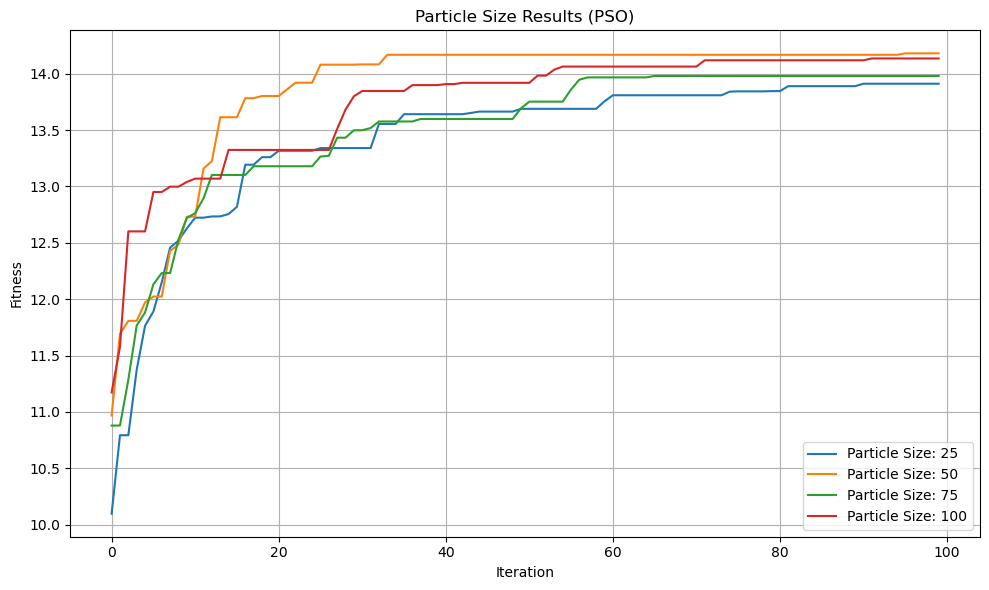

In [ ]:
plt.figure(figsize=(10, 6))

for i, result in enumerate(pso_results):
    plt.plot(result[3], label=f"Particle Size: {particle_sizes[i]}")

plt.xlabel("Iteration")
plt.ylabel("Fitness")
plt.title("Particle Size Results (PSO)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Comparison Between GA and PSO 

In [62]:
import time

# For GA
start_ga = time.time()
best_assignment, best_fitness_ga, fitness_scores = genetic_algorithm(
    df=df_input.copy(),
    population_size=50,
    generations=300,
    mutation_rate=0.2,
    num_points=20,
    verbose=True
)
end_ga = time.time()
ga_runtime = end_ga - start_ga
print(f"⏱️ GA Runtime: {ga_runtime:.2f} seconds")




Generation 1, Best Fitness: 10.8856
Generation 11, Best Fitness: 12.5796
Generation 21, Best Fitness: 13.4202
Generation 31, Best Fitness: 13.4527
Generation 41, Best Fitness: 13.6672
Generation 51, Best Fitness: 13.9062
Generation 61, Best Fitness: 14.1512
Generation 71, Best Fitness: 14.3737
Generation 81, Best Fitness: 14.3842
Generation 91, Best Fitness: 14.3952
Generation 101, Best Fitness: 14.3952
Generation 111, Best Fitness: 14.3952
Generation 121, Best Fitness: 14.4005
Generation 131, Best Fitness: 14.4005
Generation 141, Best Fitness: 14.4137
Generation 151, Best Fitness: 14.4393
Generation 161, Best Fitness: 14.4695
Generation 171, Best Fitness: 14.5142
Generation 181, Best Fitness: 14.5516
Generation 191, Best Fitness: 14.5516
Generation 201, Best Fitness: 14.5516
Generation 211, Best Fitness: 14.5516
Generation 221, Best Fitness: 14.5727
Generation 231, Best Fitness: 14.6118
Generation 241, Best Fitness: 14.6118
Generation 251, Best Fitness: 14.6118
Generation 261, Best Fi

In [56]:
# For PSO
start_pso = time.time()
best_assignment, best_fitness_pso, fitness_scores = particle_swarm_optimization(
        df=df_input.copy(),
        num_particles=50,
        iterations=100,
        num_points=20,
        verbose=True
    )
end_pso = time.time()
pso_runtime = end_pso - start_pso
print(f"⏱️ PSO Runtime: {pso_runtime:.2f} seconds")

Iteration 1, Inertia: 0.900, Best Fitness: 11.9826
Iteration 6, Inertia: 0.870, Best Fitness: 12.7130
Iteration 11, Inertia: 0.840, Best Fitness: 12.9709
Iteration 16, Inertia: 0.810, Best Fitness: 13.2901
Iteration 21, Inertia: 0.780, Best Fitness: 13.4910
Iteration 26, Inertia: 0.750, Best Fitness: 13.6075
Iteration 31, Inertia: 0.720, Best Fitness: 13.6075
Iteration 36, Inertia: 0.690, Best Fitness: 13.7940
Iteration 41, Inertia: 0.660, Best Fitness: 13.8809
Iteration 46, Inertia: 0.630, Best Fitness: 13.9316
Iteration 51, Inertia: 0.600, Best Fitness: 13.9323
Iteration 56, Inertia: 0.570, Best Fitness: 13.9323
Iteration 61, Inertia: 0.540, Best Fitness: 14.1231
Iteration 66, Inertia: 0.510, Best Fitness: 14.1757
Iteration 71, Inertia: 0.480, Best Fitness: 14.1757
Iteration 76, Inertia: 0.450, Best Fitness: 14.1907
Iteration 81, Inertia: 0.420, Best Fitness: 14.2420
Iteration 86, Inertia: 0.390, Best Fitness: 14.2687
Iteration 91, Inertia: 0.360, Best Fitness: 14.2687
Iteration 96, 

In [63]:
# === Load result files ===
ga_points = pd.read_csv("best_20_points_ga_penalty.csv")
pso_points = pd.read_csv("best_20_points_pso.csv")
top_20_points = pd.read_csv("top_20_points_direct.csv")

# === Define the evaluation function that accepts fitness & time ===
def evaluate_set(df, label, runtime_sec, best_fitness):
    coords = df[['lat', 'lon']].values
    distances = pdist(coords)
    return {
        "Method": label,
        "Best Fitness": round(best_fitness, 6),
        "Mean Score": round(df["avg_score"].mean(), 4),
        "Mean Distance (km)": round(distances.mean(), 2),
        "Min Distance (km)": round(distances.min(), 2),
        "Runtime (sec)": round(runtime_sec, 2)
    }
best_fitness_greedy = top_20_points["avg_score"].sum()

# === Build comparison table ===
results = [
    evaluate_set(top_20_points, "Top-20 Greedy", 0.01, best_fitness_greedy),
    evaluate_set(ga_points, "Genetic Algorithm", ga_runtime, best_fitness_ga),
    evaluate_set(pso_points, "Particle Swarm Optimization", pso_runtime, best_fitness_pso)
]

df_comparison = pd.DataFrame(results)
display(df_comparison)


,Method,Best Fitness,Mean Score,Mean Distance (km),Min Distance (km),Runtime (sec)
0,Top-20 Greedy,15.70134,0.7851,4.31,0.33,0.01
1,Genetic Algorithm,14.61180,0.7306,5.98,1.00,18.22
2,Particle Swarm Optimization,14.26869,0.7134,6.37,1.00,3.74


C:\Users\aya20\AppData\Local\Temp\ipykernel_10024\735342030.py:23: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
C:\Users\aya20\AppData\Local\Temp\ipykernel_10024\735342030.py:40: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from current font.
  plt.tight_layout()
C:\Users\aya20\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


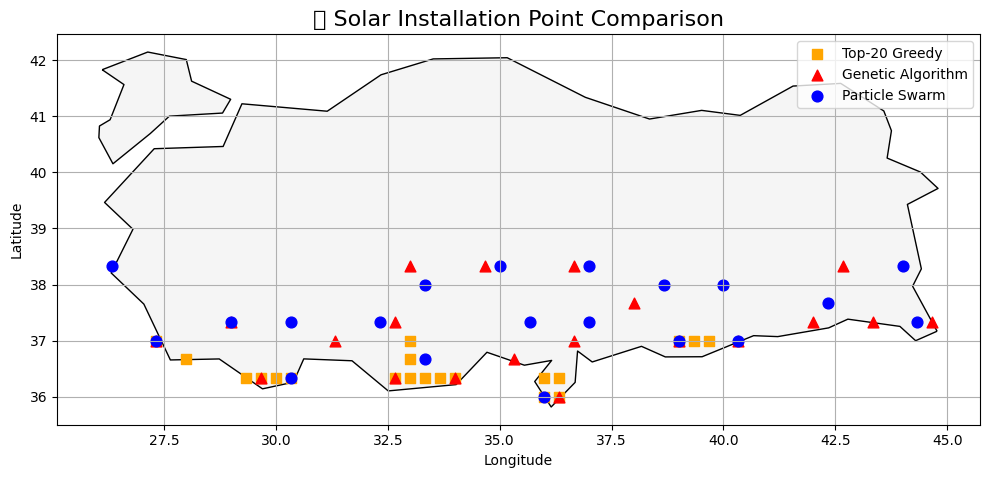

In [64]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# === Load result files ===
ga_df = pd.read_csv("best_20_points_ga_penalty.csv")
pso_df = pd.read_csv("best_20_points_pso.csv")
top20_df = pd.read_csv("top_20_points_direct.csv")

# === Convert to GeoDataFrames ===
def make_gdf(df):
    return gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326"
    )

gdf_ga = make_gdf(ga_df)
gdf_pso = make_gdf(pso_df)
gdf_top20 = make_gdf(top20_df)

# === Load Türkiye shape ===
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
turkey = world[world.name == "Turkey"]

# === Plot all three sets ===
fig, ax = plt.subplots(figsize=(10, 12))
turkey.plot(ax=ax, color='whitesmoke', edgecolor='black')

gdf_top20.plot(ax=ax, color='orange', marker='s', markersize=60, label="Top-20 Greedy")
gdf_ga.plot(ax=ax, color='red', marker='^', markersize=60, label="Genetic Algorithm")
gdf_pso.plot(ax=ax, color='blue', marker='o', markersize=60, label="Particle Swarm")

# === Labels and layout ===
plt.title("📍 Solar Installation Point Comparison", fontsize=16)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [103]:
import folium
import pandas as pd

# === Load your result files ===
ga_df = pd.read_csv("best_20_points_ga_penalty.csv")
pso_df = pd.read_csv("best_20_points_pso.csv")
top20_df = pd.read_csv("top_20_points_direct.csv")

# === Load real solar power plant data ===
solar_df = pd.read_csv("turkey_solar_filtered.csv")  # name, gppd_idnr, capacity_mw, latitude, longitude

# === Center the map over Türkiye ===
center_lat = pd.concat([ga_df, pso_df, top20_df])["lat"].mean()
center_lon = pd.concat([ga_df, pso_df, top20_df])["lon"].mean()

# === Create satellite base map ===
m = folium.Map(location=[center_lat, center_lon], zoom_start=6, tiles=None)

# ESRI Satellite
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri World Imagery",
    name="Esri Satellite",
    overlay=False,
    control=True
).add_to(m)

# === Add optimization result layers ===
def add_markers(df, name, color):
    group = folium.FeatureGroup(name=name)
    for _, row in df.iterrows():
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=6,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.85,
            popup=f"{name}<br>Score: {row['avg_score']:.4f}",
            tooltip=f"{name}<br>Score: {row['avg_score']:.4f}"
        ).add_to(group)
    group.add_to(m)

add_markers(top20_df, "Top-20 Greedy", "orange")
add_markers(ga_df, "Genetic Algorithm", "red")
add_markers(pso_df, "Particle Swarm Optimization", "blue")


# === Add real installed solar plants layer with variable size ===
solar_group = folium.FeatureGroup(name="☀ Installed Solar Plants")
for _, row in solar_df.iterrows():
    # Use square root scaling for capacity → radius (cap between 2 and 12)
    capacity = row['capacity_mw']
    radius = min(max(np.sqrt(capacity), 5), 22)  # ensures reasonable size range

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=radius,
        color="green",
        fill=True,
        fill_color="green",
        fill_opacity=0.7,
        popup=f"{row['name']}<br>{capacity:.1f} MW",
        tooltip=f"{row['name']} – {capacity:.1f} MW"
    ).add_to(solar_group)
solar_group.add_to(m)


# === Add layer control toggle ===
folium.LayerControl().add_to(m)

# === Display the map ===
m


In [86]:
# Load the installed solar power plant coordinates
solar_df = pd.read_csv("turkey_solar_power_plants.csv")

# Create a list of (lat, lon) tuples to pass into the GA as proximity references
solar_sites = list(zip(solar_df["latitude"], solar_df["longitude"]))


## GA with penalty for existing solar sites

In [102]:
import pandas as pd
import numpy as np
import random
from geopy.distance import geodesic

def genetic_algorithm(df, population_size, generations, mutation_rate, num_points=20, verbose=False, solar_sites=None):
    df = df.copy()

    def fitness_function(point_indices):
        points = df.loc[point_indices]
        suitability_score = points['avg_score'].sum()

        # --- Grid proximity penalty among selected points ---
        intra_penalty = 0
        lat_array = points['lat'].values
        lon_array = points['lon'].values

        for i in range(len(points)):
            for j in range(i + 1, len(points)):
                lat_diff_km = abs(lat_array[i] - lat_array[j]) * 111
                lon_diff_km = abs(lon_array[i] - lon_array[j]) * 86.25
                distance_km = np.sqrt(lat_diff_km**2 + lon_diff_km**2)

                if distance_km < 50:
                    intra_penalty += 1 / (distance_km + 1e-6)

        # --- Proximity penalty to real solar plants ---
                # --- Proximity penalty to real solar plants (optimized with approximate distance) ---
        proximity_penalty = 0
        if solar_sites is not None:
            for row in points.itertuples():
                for solar_lat, solar_lon in solar_sites:
                    # Approximate lat/lon distance in km (faster than geodesic)
                    lat_diff_km = abs(row.lat - solar_lat) * 111
                    lon_diff_km = abs(row.lon - solar_lon) * 86.25
                    dist = np.sqrt(lat_diff_km**2 + lon_diff_km**2)
                    if dist < 100:
                        proximity_penalty += 1/(dist + 1e-6)


        lambda_intra = 10
        lambda_prox = 5
        total_penalty = lambda_intra * intra_penalty + lambda_prox * proximity_penalty

        return suitability_score - total_penalty

    def create_initial_population():
        return [np.random.choice(df.index, num_points, replace=False) for _ in range(population_size)]

    def selection(population, fitnesses):
        indices = np.argsort(fitnesses)
        return [population[i] for i in indices[-(population_size // 2):]]

    def crossover(parent1, parent2):
        point = random.randint(1, len(parent1) - 1)
        child1 = np.concatenate((parent1[:point], parent2[point:]))
        child2 = np.concatenate((parent2[:point], parent1[point:]))
        return child1, child2

    def mutate(individual, mutation_rate):
        if random.random() < mutation_rate:
            idx = random.randint(0, len(individual) - 1)
            new_point = random.choice([i for i in df.index if i not in individual])
            individual[idx] = new_point

    fitness_scores = []
    population = create_initial_population()
    best_individual = None
    best_fitness = -float('inf')

    for generation in range(generations):
        fitnesses = [fitness_function(ind) for ind in population]

        if max(fitnesses) > best_fitness:
            best_fitness = max(fitnesses)
            best_individual = population[np.argmax(fitnesses)]

        selected = selection(population, fitnesses)
        next_generation = []

        while len(next_generation) < population_size:
            parents = random.sample(selected, 2)
            offspring1, offspring2 = crossover(parents[0], parents[1])
            mutate(offspring1, mutation_rate)
            mutate(offspring2, mutation_rate)
            next_generation.extend([offspring1, offspring2])

        population = next_generation[:population_size]

        if verbose and generation % 10 == 0:
            print(f"Generation {generation + 1}, Best Fitness: {best_fitness:.4f}")

        fitness_scores.append(best_fitness)

    best_points = df.loc[best_individual]
    best_points.to_csv('best_20_points_ga_penalty.csv', index=False)
    print("Best 20 points saved to 'best_20_points_ga_penalty.csv'")

    return best_individual, best_fitness, fitness_scores


# === Run the algorithm ===
if __name__ == "__main__":
    df_input = pd.read_csv("lat_lon_avg_score.csv")
    solar_df = pd.read_csv("turkey_solar_power_plants.csv")
    solar_sites = list(zip(solar_df["latitude"], solar_df["longitude"]))

    best_assignment, best_fitness, fitness_scores = genetic_algorithm(
        df=df_input,
        population_size=25,
        generations=100,
        mutation_rate=0.2,
        num_points=20,
        verbose=True,
        solar_sites=solar_sites
    )


Generation 1, Best Fitness: 7.5880
Generation 11, Best Fitness: 10.0113
Generation 21, Best Fitness: 10.5562
Generation 31, Best Fitness: 11.3916
Generation 41, Best Fitness: 11.7796
Generation 51, Best Fitness: 11.8946
Generation 61, Best Fitness: 12.0010
Generation 71, Best Fitness: 12.1986
Generation 81, Best Fitness: 12.7132
Generation 91, Best Fitness: 12.7132
Best 20 points saved to 'best_20_points_ga_penalty.csv'
